In [68]:
import os
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage
from langgraph.graph import StateGraph, add_messages
from openai import OpenAI
from rich.console import Console
from rich.panel import Panel
from rich.pretty import Pretty
from pydantic import BaseModel, Field
from langchain_tavily import TavilySearch
from rich import print
from langchain.agents import create_agent
from typing import Annotated, Literal, List, TypedDict
from rich.markdown import Markdown
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.output_parsers import PydanticOutputParser
from langgraph.checkpoint.memory import InMemorySaver, MemorySaver
from IPython.display import Image, display
import asyncio
from langgraph.types import Command, interrupt


console = Console()

def show(response):
    console.print(
        Panel(
            # Pretty(response.model_dump()),
            Pretty(response),
            title="🤖 LLM Response",
            border_style="green",
            expand=False
        )
    )

def show_markdown(response):
    Console().print(Markdown(response))

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

llm = ChatOpenAI(
    model="stepfun/step-3.5-flash:free",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

# llm = ChatOpenAI(
#     model="deepseek/deepseek-v3.2",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="x-ai/grok-4.1-fast",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-4o-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-oss-120b",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-5-nano",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="anthropic/claude-haiku-4.5",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash-lite",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

### Very Very Important

You’ve got the core logic right, but there is one critical correction needed regarding how LangGraph handles "past checkpoints."
LangGraph never re-executes old checkpoints. Once a checkpoint is saved, it is a permanent record of what already happened. When you invoke the graph, it only executes new steps moving forward.
Here is the corrected breakdown of your scenarios:
1. thread given + None given

* What happens: The graph looks at the very latest checkpoint in that thread and tries to resume from where it stopped.
* Result: It does not re-run the past. It looks for the next node to run. If the graph already finished (reached END), it will do nothing.

2. thread given + New state given

* What happens: This starts a brand new turn (a new "run") within the same thread.
* Result: It starts from the START node. It adds new checkpoints to the history, but it can "see" the old state (like message history) because they share the same thread_id.

3. thread + specific checkpoint + None given

* What happens: This is Time Travel. It jumps back to that specific moment and tries to continue from there.
* Result: It creates a fork. It does not change the original past; it creates a new "branch" of history starting from that old point.

4. thread + specific checkpoint + New state given

* What happens: This is Forks + Edits. You jump back to a specific moment, change the data (e.g., "What if I said 'No' instead of 'Yes'?"), and then run forward.
* Result: Just like #3, it creates a new branch, but with your modified data as the starting point for that branch.

------------------------------
Key Summary Table

| Input | Config | Execution Point | Effect |
|---|---|---|---|
| New State | thread_id only | START node | Starts a new turn in the conversation. |
| None | thread_id only | Last stopped node | Resumes an interrupted or crashed run. |
| None | checkpoint_id | Specific past node | Replays the logic from that past point. |
| New State | checkpoint_id | Specific past node | Forks history with modified data. |

The Golden Rule: LangGraph only moves forward. When you "go back" to a checkpoint, you aren't re-running the past; you are starting a new future based on an old state.

---

If your graph is interrupted and you provide a new state as input (without using Command(resume=...)), LangGraph treats this as a fork in the conversation history. [1, 2] 
Here is exactly what happens:

* Forks the History: LangGraph creates a new checkpoint that branches off from the point where the interrupt occurred. It does not "resume" the original path but starts a parallel one.
* Updates the State: The new state values you provide are merged into the existing state stored at that interrupted checkpoint.
* Restarts the Node: Because the graph was stopped mid-node, providing new input and invoking again typically causes the node that was interrupted to restart from the beginning.
* Bypasses the resume Logic: Since you didn't use Command(resume=...), the interrupt() call inside your code will not return a value. Instead, when the node restarts and hits that interrupt() line again, it will simply pause the graph once more. [2, 3, 4, 5, 6, 7, 8] 

Summary Table

| Input Method | Result | Effect on interrupt() Call |
|---|---|---|
| Command(resume=X) | Resumes | interrupt() returns X and the code continues past that line. |
| {"new_key": "val"} | Forks | Node restarts; hits interrupt() and pauses again. |

Key Takeaway: If you want the graph to actually move past the pause, you must use Command(resume=...). If you provide a new state directly, you are just editing the "memory" of the pause and asking the node to try running again from the top.

---

When you have an interrupted checkpoint, provide a new state (without a resume), and hit that same interrupt again, you have created a Fork.
Here is exactly what the "family tree" of your checkpoints looks like:
1. The Visual "Family Tree"
Imagine your thread history as a branching path:

* Checkpoint 1 (The Original): The graph ran, hit the interrupt, and stopped.
* ID: A | Parent: None (or the previous node)
* Checkpoint 2 (The Fork): You called invoke with a new state. LangGraph went back to the START node, used your new data, ran until it hit the interrupt again, and stopped.
* ID: B | Parent: A (It branched off from the state of A).

2. Continuing from the "Previous" State (Checkpoint A)
If you decide you liked the original state (A) better and want to resume from there instead of your new fork (B):

* How to do it: You must explicitly pass the checkpoint_id of A in your config.

# Target the OLD checkpoint specificallyconfig = {
    "configurable": {
        "thread_id": "my_thread",
        "checkpoint_id": "A"  # The original interrupt ID
    }
}# Resume it
graph.invoke(Command(resume="Yes"), config=config)


3. What Happens to the Checkpoint IDs?
When you resume from A, LangGraph creates a third checkpoint (C).

* The Lineage of C:
* ID: C
   * Parent ID: A
   * Status: Active/Finished (depending on if the node completes).

The Result: You now have a "V" shape in your history. Checkpoint A has two different children:

   1. Child B: Your failed "experiment" where you gave a new state but hit the interrupt again.
   2. Child C: Your successful "resume" where the graph finally moved past the interrupt.

Key Takeaways

* Nothing is deleted: Checkpoint B (the new state fork) still exists in the database. You can jump back to it anytime.
* The "Latest" Default: If you don't specify a checkpoint_id, LangGraph always defaults to the most recent one (which would be B). To go back to A, you must be explicit.
* State Separation: The "New State" you sent to create B does not exist in the timeline of C. C only knows what was in A plus your resume value.

---

In LangGraph, Command, goto, and interrupt are the core building blocks for Human-in-the-Loop workflows and dynamic control over how your agent moves between steps. [1] 
1. interrupt()
The interrupt() function is used inside a node to pause execution and wait for external input. [2, 3] 

* What it does: When called, it saves the current state to your checkpointer and returns control to the caller.
* The Resume Loop: When you later resume the graph, it restarts the entire node from the beginning. This time, the interrupt() call does not pause; instead, it returns the value you provided when resuming.
* Usage: Perfect for asking a human for approval (e.g., "Do you want to buy this stock?") or asking for missing information. [1, 3, 4, 5, 6, 7, 8] 

2. Command
Command is a special object that nodes return to tell LangGraph exactly what to do next. It combines state updates and routing into a single return value. [9] 

* As an Input: You use Command(resume="some_value") to restart a graph that was paused by an interrupt().
* As a Return: Inside a node, you return it to update the state and navigate to the next step simultaneously. [5, 9, 10, 11] 

3. goto
The goto parameter is used within a Command object to perform dynamic routing. [9, 12] 

* What it does: It tells the graph exactly which node to run next, effectively bypassing or supplementing your pre-defined edges.
* Flexibility: You can use a string for a single node (e.g., goto="my_node") or a list for parallel execution (e.g., goto=["node_a", "node_b"]).
* Key Detail: Returning a Command(goto=...) from a node adds a dynamic edge; it does not automatically cancel any static edges you already defined with add_edge. [9, 12, 13, 14] 

Example Workflow


from langgraph.types import interrupt, Command
def human_approval_node(state):
    # 1. Interrupt pauses here and waits for user input
    user_decision = interrupt("Do you approve this action?")
    
    if user_decision == "approve":
        # 2. Use Command and goto to route dynamically
        return Command(
            update={"status": "approved"}, 
            goto="execute_action"
        )
    return {"status": "rejected"}
To Resume: graph.invoke(Command(resume="approve"), config=config)

---

In LangGraph, the return type hint for a node should technically be a dict (specifically a Partial version of your state), but because LangGraph is flexible, most developers use one of these three options depending on how strict they want to be:
1. The "Standard" Way (Recommended)
Since you are returning a dictionary that only contains the changes (the delta), you can simply hint it as a dict.

def executor(state: GraphState) -> dict:
    return {
        "messages": [f"Msg {state.counter}"], 
        "counter": state.counter + 1
    }

2. The "Strict" Way (Best for IDEs)
If you want your code editor (like VS Code or PyCharm) to know exactly which fields are being returned, you can use your Pydantic model as the hint. Even though you are returning a dict, LangGraph's internal logic treats the return as a "partial" update to that model.

def executor(state: GraphState) -> GraphState:
    # Your IDE will now check if 'messages' and 'counter' 
    # actually exist in GraphState
    return {
        "messages": [f"Msg {state.counter}"], 
        "counter": state.counter + 1
    }

3. The "Dynamic" Way (With Command)
If your node uses goto or interrupt, you must use the Command type hint.

from langgraph.types import Command
def executor(state: GraphState) -> Command:
    return Command(
        update={"messages": ["Hello"], "counter": 1},
        goto="next_node"
    )

Why a dict is better than returning the state object:

* The Reducer Trigger: When you return {"messages": ["new"]}, LangGraph sees the add_messages annotation and says "I need to append this."
* The Overwrite Trigger: If you return the whole GraphState object, LangGraph often sees it as a single unit and might overwrite the entire list instead of appending, depending on the specific checkpointer version.

Pro Tip: If you want to be 100% type-safe, you can use TypedDict for the return hint, but dict is the "everyday" choice for most LangGraph users.
Do you want to see how to use TypedDict to make your node returns even more precise?

---

A TypedDict is a special type hint in Python (introduced in 3.8) that allows you to define a fixed schema for a regular dictionary. [1, 2] 
While a normal dictionary (dict) is just a collection of any keys and values, a TypedDict tells your code editor exactly which string keys must exist and what type of data each key should hold. [3, 4] 
How it looks

from typing import TypedDict
class UserProfile(TypedDict):
    name: str
    age: int
    is_active: bool
This is still just a plain dictionary at runtime!user: UserProfile = {"name": "Alice", "age": 30, "is_active": True}

Key Characteristics

* Static Type Checking: It is designed for tools like mypy or your IDE (VS Code/PyCharm) to catch errors before you run the code (e.g., if you mistype a key as "nme" instead of "name").
* Plain Dictionary at Runtime: Unlike a Pydantic model or a Class, a TypedDict doesn't exist when the code is actually running. It is just a standard Python dict.
* No Runtime Validation: If you pass a string where an integer is expected, a TypedDict will not stop you or throw an error while the program is running.
* Totality: By default, all keys defined in a TypedDict are required. You can change this by setting total=False, which makes all keys optional. [1, 2, 5, 6, 7, 8, 9, 10] 

Comparison for LangGraph State

| Feature [1, 9, 11] | dict | TypedDict | Pydantic (BaseModel) |
|---|---|---|---|
| Structure | Flexible/Unknown | Fixed Schema | Fixed Schema |
| Validation | None | Static Only (Editor hints) | Runtime (Stops bad data) |
| Performance | Fastest | Lightweight | Slightly slower (due to checks) |
| Best For | Quick scripts | Standard LangGraph nodes | Production-ready APIs |

In LangGraph, using a TypedDict is a great middle ground: it gives you perfect autocomplete in your nodes without the extra "weight" of full data validation at every step. [7] 


In reality, at runtime (when the code is actually running), a node returns a plain Python dict.
A TypedDict is just a "label" for humans and IDEs. Once your code starts, that label disappears, and only a standard dictionary remains.
Here’s the "Under the Hood" reality:

   1. The Code: You write return {"counter": 5}.
   2. The Type Hint: You tell your editor: "This dictionary follows the MyResponse(TypedDict) schema."
   3. The Execution: LangGraph receives a standard dict. It doesn't care if you hinted it as a TypedDict, a dict, or nothing at all.
   4. The Merge: LangGraph takes that dict and merges it into your main State.

Why we use TypedDict if it's "just a dict"?
If you use a plain dict, your editor is "blind":

def my_node(state) -> dict:
    return {"cont": 5}  # Typo! Editor says nothing. Graph fails at runtime.

If you use TypedDict, your editor is "smart":

class MyResponse(TypedDict):
    counter: int
def my_node(state) -> MyResponse:
    return {"cont": 5}  # ERROR: Editor highlights "cont" because it's not in MyResponse.

The Best Practice

* The State: Use Pydantic (BaseModel) because it actually validates the data while the graph is running (e.g., it will crash if a tool tries to send a string into an integer field).
* The Node Return: Use TypedDict (or just dict) because nodes are just "messengers" sending small updates to the main state.

Summary: Your node returns a dict, but you describe it as a TypedDict so you don't make typos.
Would you like to see how to use Annotated within a TypedDict to make sure your messages append instead of overwrite?



In the life cycle of a LangGraph execution, Pydantic acts as the Gatekeeper at every single step. Even though your nodes return simple dictionaries, Pydantic is working behind the scenes in three specific places:
1. The Input Check (The Front Door)
The moment you call graph.invoke(data, config), LangGraph passes that data into your Pydantic State class.

* What happens: Pydantic validates that you provided all required fields and that the types (strings, ints, lists) match.
* If it fails: The graph crashes before the first node even runs, giving you a clear error message.

2. The Merge & Validation (Between Every Node)
This is the most critical part. When a node finishes and returns a dict:

   1. The Return: Your node returns {"counter": 5}.
   2. The Merger: LangGraph takes that dictionary and "applies" it to the current State.
   3. The Re-Validation: Pydantic immediately checks the entire State again.
   * It ensures the new counter is an integer.
      * It triggers any Reducers (like add_messages) to append data.
      * It ensures no required fields were accidentally deleted.
   
3. The Checkpoint (The Filing Cabinet)
When using a Memory Saver or database:

* Serialization: Pydantic handles converting your complex objects (like Chat Messages) into a format that can be saved as JSON in a database.
* Deserialization: When you resume a thread, Pydantic turns that raw JSON back into a rich Python object so your nodes can use .dot_notation to access data.

------------------------------
Summary: The "Sandwich" Flow

| Step | Data Type | Who is handling it? |
|---|---|---|
| Start | dict | You (via invoke) |
| Validation | Pydantic Model | LangGraph + Pydantic |
| Node Runs | Pydantic Model | Your code (reads the state) |
| Node Returns | dict | Your code (returns the delta) |
| Merge/Check | Pydantic Model | LangGraph + Pydantic |
| Save to Memory | JSON/Binary | Checkpointer |

Think of it like this: Your nodes are the workers passing around sticky notes (dict), but the Manager (Pydantic) keeps the official ledger (State) and makes sure every sticky note follows the rules before writing it down.
Would you like to see what happens when a node returns the wrong data type and how Pydantic catches it?

---

In [76]:
class graph_state(BaseModel):
    messages: List[str]
    counter: int

In [86]:
def executor(state: graph_state) -> Command:
    decision = interrupt({
        'question': "Approve this action?",
        'details': f'{state.counter}: {state.messages}'
    })
    if decision:
        messages = state.messages
        counter = state.counter
        new_message = f"Message number {counter}"
        return Command(
            update = {
                'messages': messages + [new_message],
                'counter': counter + 1
            },
            goto = 'executor'
        )
    else:
        return Command(
            goto = END
        )

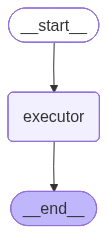

In [87]:
graph = StateGraph(graph_state)

graph.add_node('executor', executor)

graph.add_edge(START, 'executor')
graph.add_edge('executor', END)

checkpointer = MemorySaver()

hitl_graph = graph.compile(checkpointer = checkpointer)

Image(hitl_graph.get_graph().draw_mermaid_png())

In [88]:
config1 = {"configurable": {"thread_id": 'a'}}
resp1 = hitl_graph.invoke(
    graph_state(messages = [], counter = 0),
    config=config1,
)

In [89]:
show(resp1)

╭────────────────────────────── 🤖 LLM Response ──────────────────────────────╮
│ {                                                                           │
│     'messages': [],                                                         │
│     'counter': 0,                                                           │
│     '__interrupt__': [                                                      │
│         Interrupt(                                                          │
│             value={                                                         │
│                 'question': 'Approve this action?',                         │
│                 'details': '0: []'                                          │
│             },                                                              │
│             id='bcc8335beea9ba7147b7ed83beb2221e'                           │
│         )                                                                   │
│     ]                                                                       │
│ }                                                                           │
╰─────────────────────────────────────────────────────────────────────────────╯

In [90]:
resp2 = hitl_graph.invoke(
    {'count': 2},
    config=config1,
)

In [92]:
show(resp2)

╭────────────────────────────── 🤖 LLM Response ──────────────────────────────╮
│ {                                                                           │
│     'messages': [],                                                         │
│     'counter': 0,                                                           │
│     '__interrupt__': [                                                      │
│         Interrupt(                                                          │
│             value={                                                         │
│                 'question': 'Approve this action?',                         │
│                 'details': '0: []'                                          │
│             },                                                              │
│             id='8de994f16ed9ad36074dd41d36efd57f'                           │
│         )                                                                   │
│     ]                                                                       │
│ }                                                                           │
╰─────────────────────────────────────────────────────────────────────────────╯

In [93]:
history = hitl_graph.get_state_history({'configurable':{'thread_id': 'a'}})
print(history)
for i, state in enumerate(history):
    print(i, state)

<generator object Pregel.get_state_history at 0x0000026C66E1A560>

Deserializing unregistered type __main__.graph_state from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'graph_state')]


0
StateSnapshot(
    values={'messages': [], 'counter': 0},
    next=('executor',),
    config={
        'configurable': {
            'thread_id': 'a',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125fb5-8301-68bb-8002-6b39cb3711c1'
        }
    },
    metadata={'source': 'loop', 'step': 2, 'parents': {}},
    created_at='2026-03-22T14:28:07.176210+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'a',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125fb5-8301-68ba-8001-305a105cabaa'
        }
    },
    tasks=(
        PregelTask(
            id='f8233478-15e7-a1bf-467b-ecc9f9188f48',
            name='executor',
            path=('__pregel_pull', 'executor'),
            error=None,
            interrupts=(
                Interrupt(
                    value={'question': 'Approve this action?', 'details': '0: []'},
                    id='8de994f16ed9ad36074dd41d36efd57f'
                ),
            ),
            state=None,
            result=None
        ),
    ),
    interrupts=(
        Interrupt(
            value={'question': 'Approve this action?', 'details': '0: []'},
            id='8de994f16ed9ad36074dd41d36efd57f'
        ),
    )
)

1
StateSnapshot(
    values={'messages': [], 'counter': 0},
    next=('__start__',),
    config={
        'configurable': {
            'thread_id': 'a',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125fb5-8301-68ba-8001-305a105cabaa'
        }
    },
    metadata={'source': 'input', 'step': 1, 'parents': {}},
    created_at='2026-03-22T14:28:07.176210+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'a',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125fb3-625a-66b0-8000-0f262ce8bc1e'
        }
    },
    tasks=(
        PregelTask(
            id='db87e19f-8ae3-3fe1-e26b-f528cf877b9a',
            name='__start__',
            path=('__pregel_pull', '__start__'),
            error=None,
            interrupts=(),
            state=None,
            result={}
        ),
    ),
    interrupts=()
)

2
StateSnapshot(
    values={'messages': [], 'counter': 0},
    next=('executor',),
    config={
        'configurable': {
            'thread_id': 'a',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125fb3-625a-66b0-8000-0f262ce8bc1e'
        }
    },
    metadata={'source': 'loop', 'step': 0, 'parents': {}},
    created_at='2026-03-22T14:27:10.065220+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'a',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125fb3-6257-6f60-bfff-e5f520792e03'
        }
    },
    tasks=(
        PregelTask(
            id='e09f3958-1a50-7282-99df-d3d9cd832eb8',
            name='executor',
            path=('__pregel_pull', 'executor'),
            error=None,
            interrupts=(
                Interrupt(
                    value={'question': 'Approve this action?', 'details': '0: []'},
                    id='bcc8335beea9ba7147b7ed83beb2221e'
                ),
            ),
            state=None,
            result=None
        ),
    ),
    interrupts=(
        Interrupt(
            value={'question': 'Approve this action?', 'details': '0: []'},
            id='bcc8335beea9ba7147b7ed83beb2221e'
        ),
    )
)

3
StateSnapshot(
    values={},
    next=('__start__',),
    config={
        'configurable': {
            'thread_id': 'a',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125fb3-6257-6f60-bfff-e5f520792e03'
        }
    },
    metadata={'source': 'input', 'step': -1, 'parents': {}},
    created_at='2026-03-22T14:27:10.064214+00:00',
    parent_config=None,
    tasks=(
        PregelTask(
            id='9c1a723f-a30c-f915-d6c1-0809039a4064',
            name='__start__',
            path=('__pregel_pull', '__start__'),
            error=None,
            interrupts=(),
            state=None,
            result={'messages': [], 'counter': 0}
        ),
    ),
    interrupts=()
)